In [36]:
"""Project dataset: The dataset MNIST contains 60,000 samples, composed entirely of small, grayscale images of handwritten digits, from 0 to 9.
Every single image comes with a label that correctly identifies which digit (0, 1, 2, etc.) it is. 
This makes it a perfect dataset for supervised learning, where the model learns by comparing its predictions to the correct answer"""

#importing libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
%matplotlib inline

In [38]:
#using pandas to read the database stored in the same folder
data=pd.read_csv("mnist_train.csv")
data1=pd.read_csv("mnist_test.csv")

In [39]:
#viewing colum heads
data.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
#extracting data from the dataset and viewing them upclose
a=data.iloc[2,1:].values

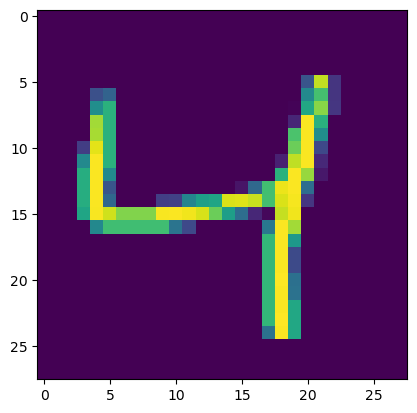

In [41]:
#reshaping extracted data
a=a.reshape(28,28).astype('uint8')
plt.imshow(a)
plt.show()

In [42]:
#preparing the data
#separating labels and data values
df_x=data.iloc[:,1:]
df_y=data.iloc[:,0]

In [48]:
#creating train and test sizes
x_train, x_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.2, random_state=4)

In [50]:
#checking data 
x_train.head()

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
20379,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
53032,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
30510,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
508,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
#checking data 
y_train.head()

20379    4
53032    4
27005    7
30510    8
508      1
Name: label, dtype: int64

In [62]:
#call rf_classifier
rf=RandomForestClassifier(n_estimators=100)

In [63]:
#fitting model
rf.fit(x_train, y_train)

RandomForestClassifier()

In [64]:
#prediction on test data
pred=rf.predict(x_test)
print(pred)

[2 7 6 ... 6 4 2]


In [65]:
#checking precition accuracy
s=y_test.values
#calculating number of correctly predicted values
count=0
for i in range(len(pred)):
    if pred[i]==s[i]:
        count+=1

print(count)

11612


In [66]:
#total number of values
print(len(pred))
#accuracy
acc=count/len(pred)
print("Model Accuracy using Random Forest Classifier is=",round(acc*100,4),end="%")

12000
Model Accuracy using Random Forest Classifier is= 96.7667%

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [61]:
print("\n\n--- Detailed Model Evaluation ---")

# 1. Accuracy Score (from scikit-learn)
acc_sklearn = accuracy_score(y_test, pred)
print(f"Scikit-learn Accuracy Score: {acc_sklearn * 100:.4f}%")

# For multi-class classification (like MNIST), we must specify an
# averaging method. 'macro' calculates the metric for each class
# independently and then takes the unweighted average.
avg_method = 'macro'

# 2. Precision Score
precision = precision_score(y_test, pred, average=avg_method)
print(f"Precision Score ({avg_method} average): {precision*100:.4f}")

# 3. Recall Score
recall = recall_score(y_test, pred, average=avg_method)
print(f"Recall Score ({avg_method} average): {recall*100:.4f}")

# 4. F1 Score
# The F1 score is the harmonic mean of precision and recall
f1 = f1_score(y_test, pred, average=avg_method)
print(f"F1 Score ({avg_method} average): {f1*100:.4f}")

# 5. ROC AUC Score
# For ROC AUC in a multi-class setting, you need the predicted
# probabilities for each class, not just the final prediction.
pred_proba = rf.predict_proba(x_test)

# We also specify the multi-class strategy, e.g., 'ovr' (One-vs-Rest),
# which computes the AUC for each class against all others.
roc_auc = roc_auc_score(y_test, pred_proba, multi_class='ovr')
print(f"ROC AUC Score (One-vs-Rest): {roc_auc*100:.4f}")



--- Detailed Model Evaluation ---
Scikit-learn Accuracy Score: 96.8667%
Precision Score (macro average): 96.8483
Recall Score (macro average): 96.8365
F1 Score (macro average): 96.8400
ROC AUC Score (One-vs-Rest): 99.8929
